In [1]:
!pip install tensorflow

In [20]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras. layers import Dense, Flatten
from tensorflow.keras.utils import to_categorical

In [9]:
import matplotlib.pyplot as plt

In [11]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step


In [12]:
print(f"Training data shape is {x_train.shape}")

Training data shape is (60000, 28, 28)


In [13]:
print(f"Test data shape is {x_test.shape}")

Test data shape is (10000, 28, 28)


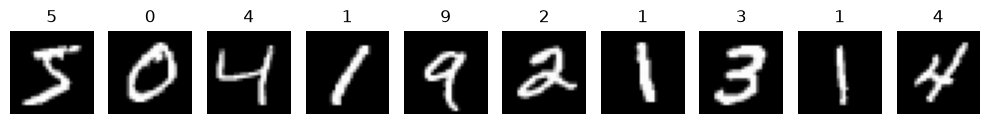

In [16]:
plt.figure(figsize=(10,2))
for i in range(10):
    plt.subplot(1, 10, i+1)
    plt.imshow(x_train[i], cmap="gray")
    plt.axis("off")
    plt.title(str(y_train[i]))
plt.tight_layout()
plt.show()

In [21]:
# Normalize the input data
x_train = x_train / 255.0
x_test = x_test / 255.0

# One-hot encode the labels
y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

In [22]:
model = Sequential([
 Flatten(input_shape=(28, 28)), 
 Dense(128, activation='relu'), 
 Dense(10, activation='softmax') 
])

D:\anaconda\envs\tf_env\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [23]:
model.compile(
 optimizer='adam',
 loss='categorical_crossentropy',
 metrics=['accuracy'])

In [24]:
model.fit(x_train, y_train, epochs=5, batch_size=32)

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.7155 - loss: 1.1540
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8746 - loss: 0.4779
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8966 - loss: 0.3762
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - accuracy: 0.9054 - loss: 0.3353
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9110 - loss: 0.3117


In [25]:
test_loss, test_acc = model.evaluate(x_test, y_test)
print(f"Test accuracy: {test_acc:.4f}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9146 - loss: 0.2970
Test accuracy: 0.9146
